# SIS 2
## Title: Predicting Whether a Client Will Subscribe to a Term Deposit
**Dataset:** Bank Marketing 


## STEP 0: Install & Import Libraries

In [39]:
%pip install ucimlrepo xgboost lightgbm imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')


Note: you may need to restart the kernel to use updated packages.


## STEP 1: Load the Dataset

In [40]:
bank_marketing = fetch_ucirepo(id=222)

X_raw = bank_marketing.data.features
y_raw = bank_marketing.data.targets

df = X_raw.copy()
df['y'] = y_raw.values.ravel()

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Dataset shape: (45211, 17)
Rows: 45,211
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## STEP 2: Exploratory Data Analysis (EDA)

Before training anything, we need to understand the data — features, missing values, class balance, and key patterns.

In [41]:
print('STEP 2.1: BASIC DATASET DESCRIPTION')

print('\n Data Types ')
print(df.dtypes)

print('\n Basic Statistics')
display(df.describe())

print('\n Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values! ')

STEP 2.1: BASIC DATASET DESCRIPTION

 Data Types 
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

 Basic Statistics


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



 Missing Values
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


**Interpretation:** The dataset has 45,211 rows and 17 features — a mix of numerical (age, balance, duration) and categorical (job, marital, contact, etc.). The target `y` is binary: `yes` (subscribed) or `no`. No missing values, so imputation is not needed.

STEP 2.2: CLASS DISTRIBUTION
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


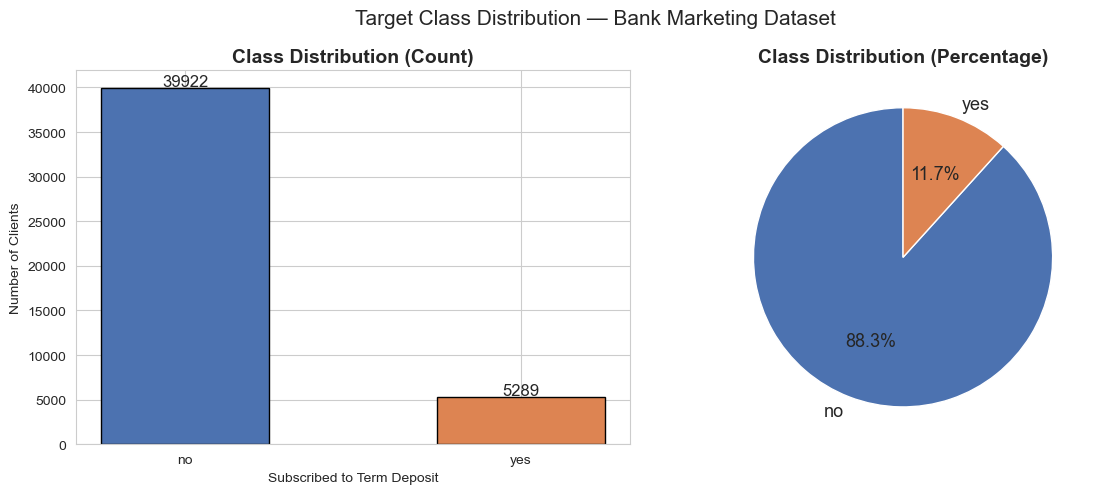

Caption: ~88.5% no vs ~11.5% yes — heavily imbalanced. We will use SMOTE to handle this.


In [42]:
print('STEP 2.2: CLASS DISTRIBUTION')

class_counts = df['y'].value_counts()
class_pct = df['y'].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452']

axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Number of Clients')
for i, (label, count) in enumerate(class_counts.items()):
    axes[0].text(i, count + 200, str(count), ha='center', fontsize=12)

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.suptitle('Target Class Distribution — Bank Marketing Dataset', fontsize=15)
plt.tight_layout()
plt.show()
print('Caption: ~88.5% no vs ~11.5% yes — heavily imbalanced. We will use SMOTE to handle this.')

**Interpretation:** The dataset is heavily imbalanced — ~88.5% `no`, ~11.5% `yes`. A naive model predicting always `no` would get 88.5% accuracy but be useless. We address this with SMOTE during preprocessing.

STEP 2.3: CATEGORICAL FEATURES vs TARGET


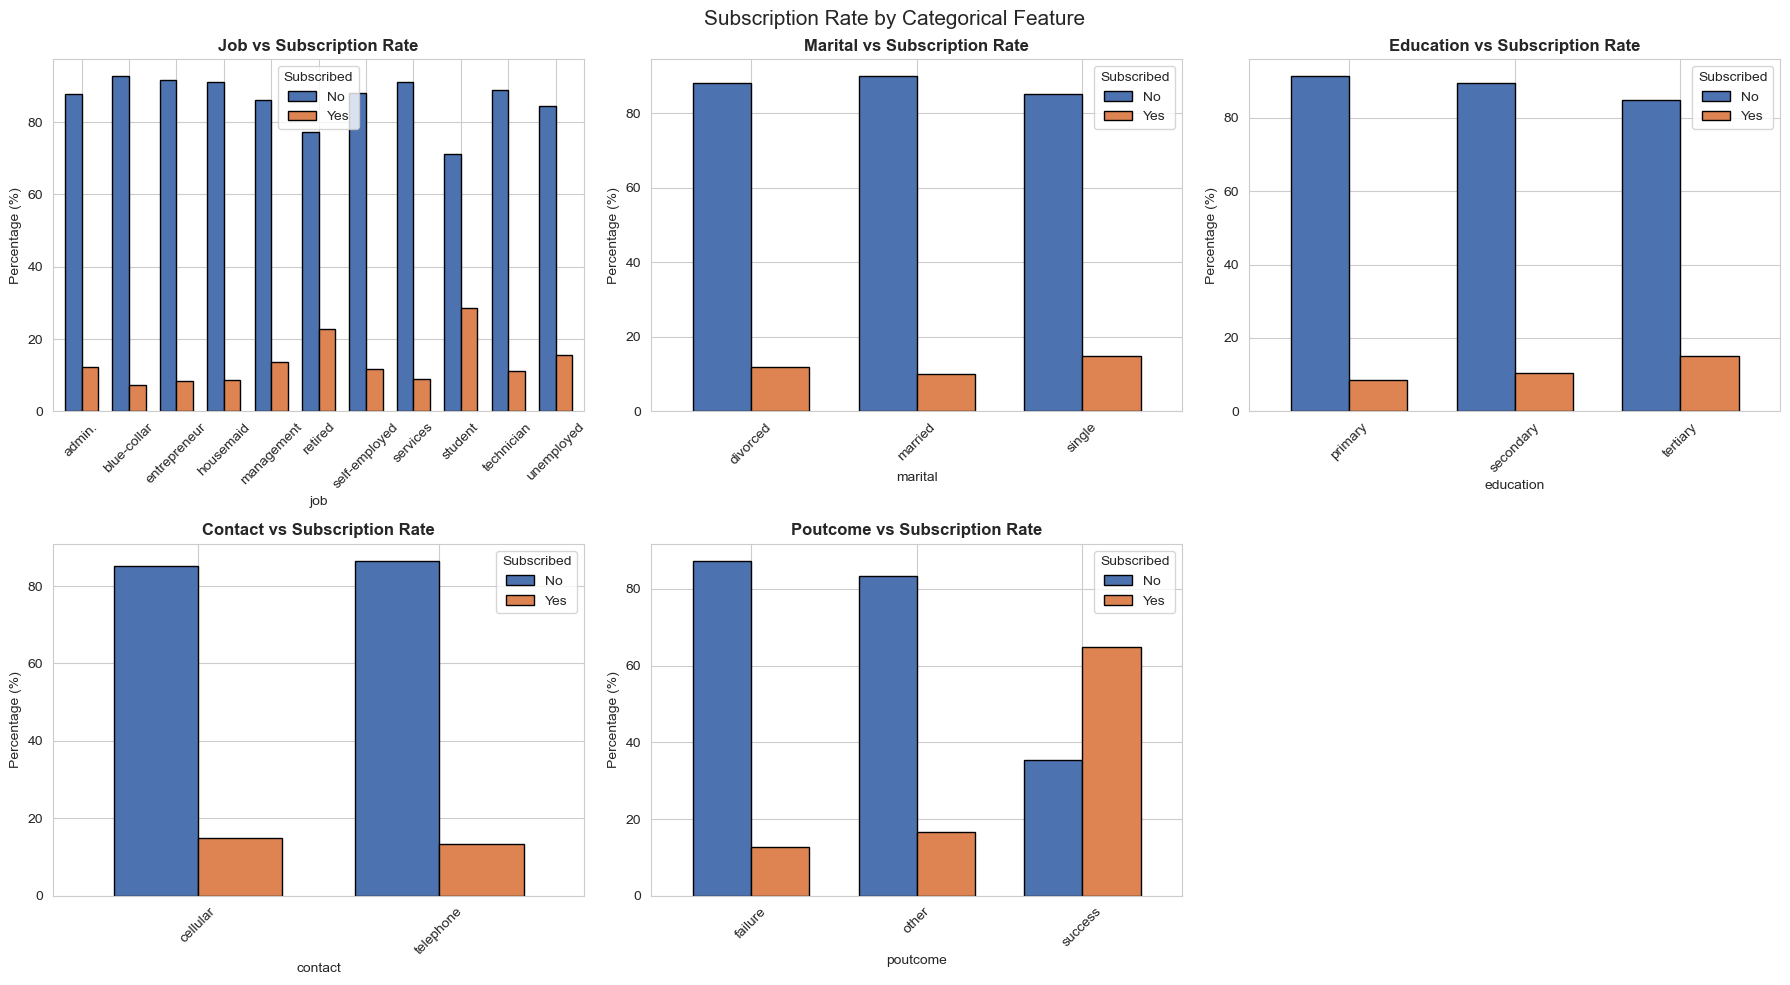

Caption: Subscription rate varies strongly by category. poutcome=success and job=student/retired show highest subscription rates.


In [43]:
print('STEP 2.3: CATEGORICAL FEATURES vs TARGET')

cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.7)
    axes[i].set_title(f'{col.capitalize()} vs Subscription Rate', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No', 'Yes'], title='Subscribed')
    axes[i].tick_params(axis='x', rotation=45)

axes[5].axis('off')
plt.suptitle('Subscription Rate by Categorical Feature', fontsize=15)
plt.tight_layout()
plt.show()
print('Caption: Subscription rate varies strongly by category. poutcome=success and job=student/retired show highest subscription rates.')

**Interpretation:** Key findings — `poutcome=success` is the strongest predictor (clients who subscribed before do so again). Students and retired clients subscribe more often. Cellular contact outperforms telephone.

STEP 2.4: NUMERICAL FEATURES vs TARGET


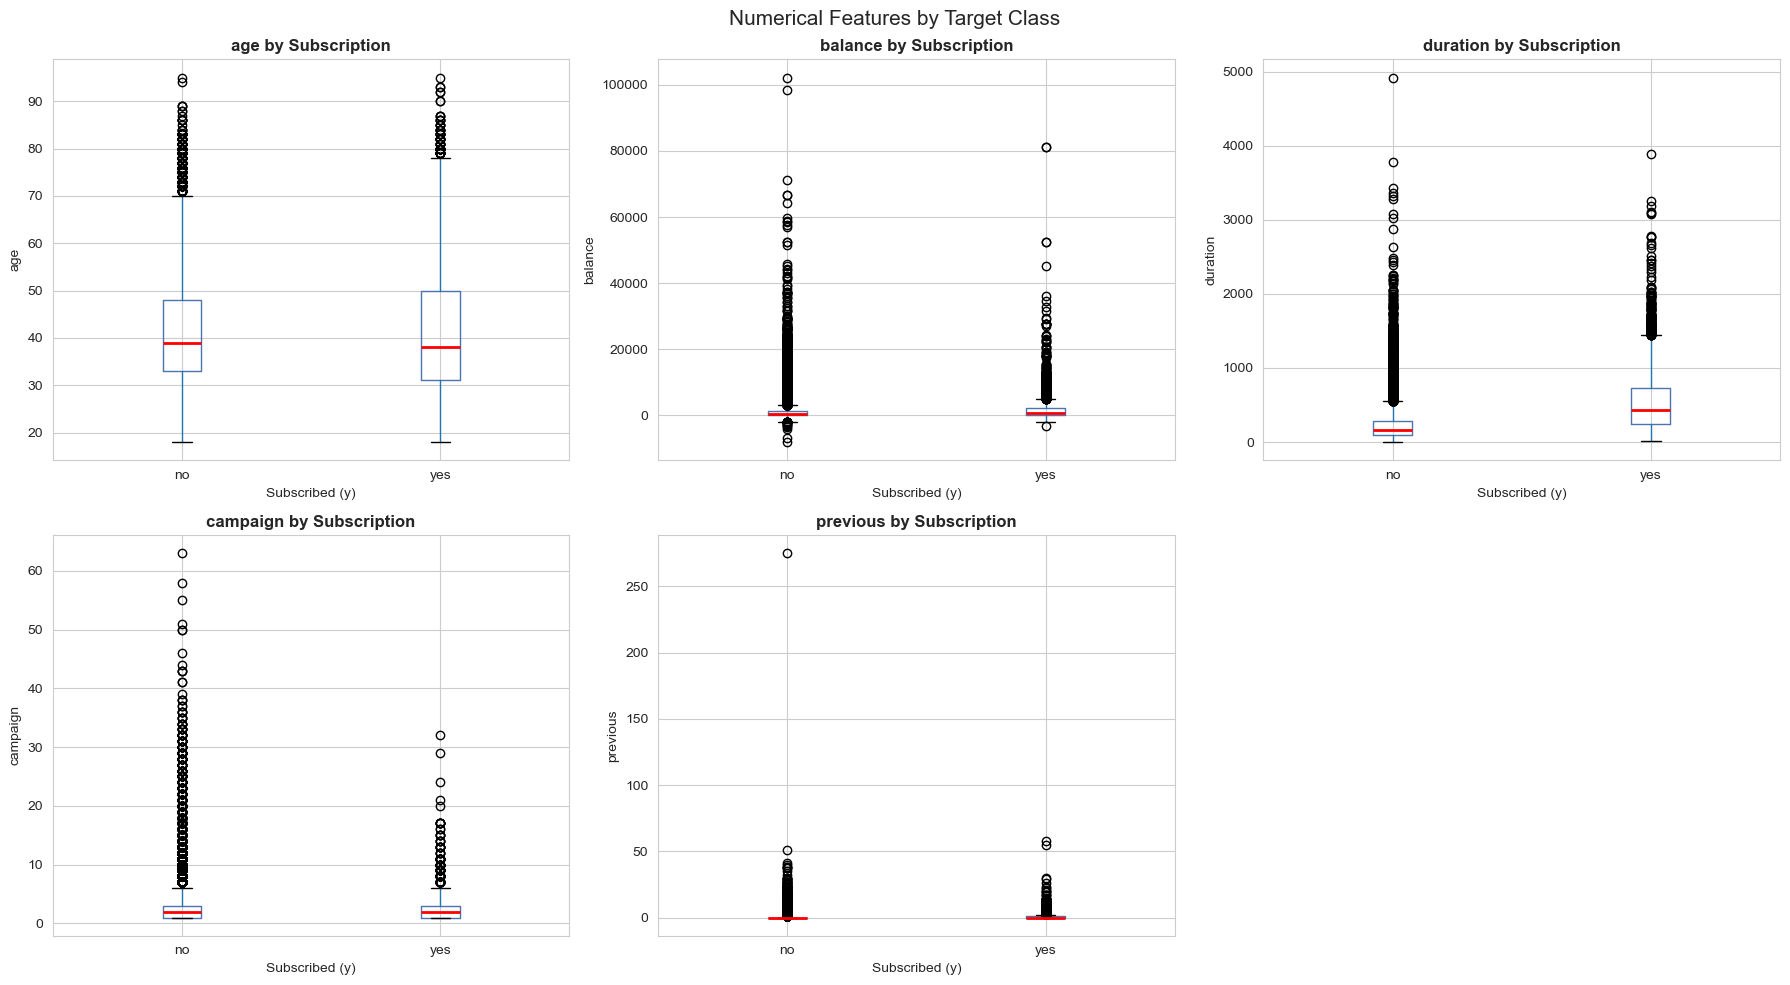

Caption: duration shows the clearest separation — longer calls strongly predict subscription.


In [44]:
print('STEP 2.4: NUMERICAL FEATURES vs TARGET')

num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='y', ax=axes[i],
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Subscription', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Subscribed (y)')
    axes[i].set_ylabel(col)

axes[5].axis('off')
plt.suptitle('Numerical Features by Target Class', fontsize=15)
plt.tight_layout()
plt.show()
print('Caption: duration shows the clearest separation — longer calls strongly predict subscription.')

**Interpretation:** `duration` (call length) is the strongest numerical predictor — subscribers had much longer calls. `campaign` (number of contacts) is slightly lower for subscribers, suggesting aggressive calling is counterproductive.

STEP 2.5: CORRELATION HEATMAP


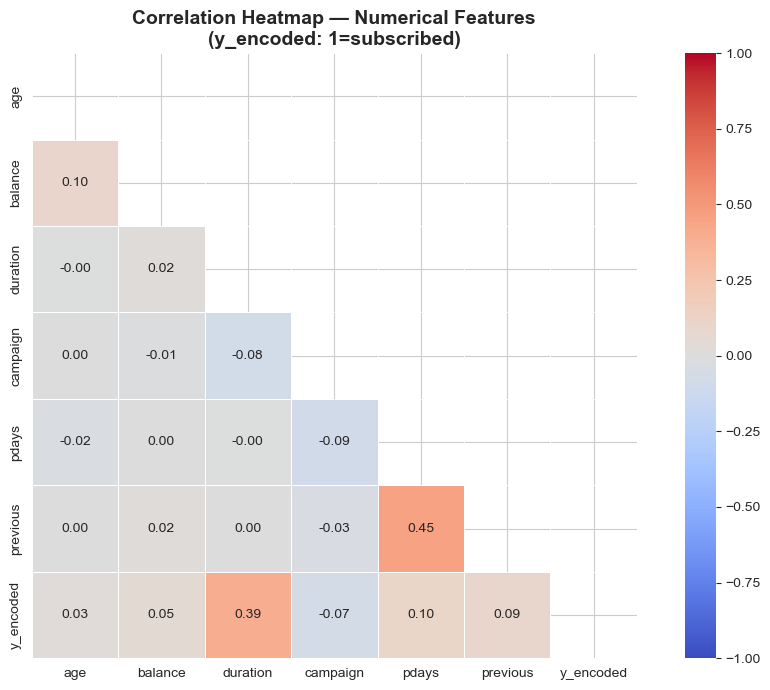

Caption: duration has the highest correlation with target (r~0.39). campaign is slightly negative.


In [45]:
print('STEP 2.5: CORRELATION HEATMAP')

df_corr = df.copy()
df_corr['y_encoded'] = (df_corr['y'] == 'yes').astype(int)
num_features_corr = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y_encoded']
corr_matrix = df_corr[num_features_corr].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features\n(y_encoded: 1=subscribed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Caption: duration has the highest correlation with target (r~0.39). campaign is slightly negative.')

**Interpretation:** `duration` has the strongest positive correlation with target (r ≈ 0.39). Most features have low inter-correlation, indicating low multicollinearity — good for model stability.

## STEP 3: Data Preprocessing

Steps: encode target → identify feature types → OneHotEncode categoricals → StandardScale numericals → train/test split → SMOTE for imbalance.

In [46]:
print('STEP 3.1: ENCODE TARGET & IDENTIFY FEATURE TYPES')

y = (df['y'] == 'yes').astype(int)
X = df.drop('y', axis=1)

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_features = [f for f in num_features if f != 'day_of_week']
cat_features = cat_features + ['day_of_week']

print(f'Categorical features ({len(cat_features)}): {cat_features}')
print(f'Numerical features ({len(num_features)}): {num_features}')
print(f'\nAll columns: {list(X.columns)}')

STEP 3.1: ENCODE TARGET & IDENTIFY FEATURE TYPES
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'day_of_week']
Numerical features (6): ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

All columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [47]:
print('STEP 3.2: BUILD PREPROCESSING PIPELINE')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

print('ColumnTransformer created:')
print(f'  StandardScaler on {len(num_features)} numerical columns')
print(f'  OneHotEncoder on {len(cat_features)} categorical columns')

STEP 3.2: BUILD PREPROCESSING PIPELINE
ColumnTransformer created:
  StandardScaler on 6 numerical columns
  OneHotEncoder on 10 categorical columns


In [48]:
print('STEP 3.3: TRAIN-TEST SPLIT (80/20, STRATIFIED)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Train distribution: {y_train.value_counts().to_dict()}')
print(f'Test distribution:  {y_test.value_counts().to_dict()}')

STEP 3.3: TRAIN-TEST SPLIT (80/20, STRATIFIED)
Training set: (36168, 16)
Test set:     (9043, 16)
Train distribution: {0: 31937, 1: 4231}
Test distribution:  {0: 7985, 1: 1058}


In [49]:
print('STEP 3.4: FIT PREPROCESSOR & TRANSFORM')

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed train shape: {X_train_proc.shape}')
print(f'Processed test shape:  {X_test_proc.shape}')
print(f'(Features expanded from 16 to {X_train_proc.shape[1]} after one-hot encoding)')

STEP 3.4: FIT PREPROCESSOR & TRANSFORM
Processed train shape: (36168, 81)
Processed test shape:  (9043, 81)
(Features expanded from 16 to 81 after one-hot encoding)


In [50]:
print('STEP 3.5: SMOTE — HANDLE CLASS IMBALANCE')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

before = dict(zip(*np.unique(y_train, return_counts=True)))
after  = dict(zip(*np.unique(y_train_bal, return_counts=True)))
print(f'Before SMOTE: {before}')
print(f'After SMOTE:  {after}')
print(f'Training size after SMOTE: {X_train_bal.shape}')

STEP 3.5: SMOTE — HANDLE CLASS IMBALANCE
Before SMOTE: {np.int64(0): np.int64(31937), np.int64(1): np.int64(4231)}
After SMOTE:  {np.int64(0): np.int64(31937), np.int64(1): np.int64(31937)}
Training size after SMOTE: (63874, 81)


**Interpretation:** SMOTE creates synthetic minority-class samples by interpolating between existing ones. After SMOTE both classes have equal representation. Applied **only on training data** — test set stays original to reflect real-world distribution.

## STEP 4: Model Training

We train 6 models: Logistic Regression, Decision Tree, Random Forest, KNN, SVM (LinearSVC — fast linear SVM), and XGBoost.

In [51]:
print('STEP 4: TRAINING ALL MODELS')


models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM (Linear)':        CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0)
}

predictions   = {}
probabilities = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_bal, y_train_bal)
    predictions[name]   = model.predict(X_test_proc)
    probabilities[name] = model.predict_proba(X_test_proc)[:, 1]
    print(f'  {name} done!')

print('\nAll models trained')

STEP 4: TRAINING ALL MODELS
Training Logistic Regression...
  Logistic Regression done!
Training Decision Tree...
  Decision Tree done!
Training Random Forest...
  Random Forest done!
Training KNN...
  KNN done!
Training SVM (Linear)...
  SVM (Linear) done!
Training XGBoost...
  XGBoost done!

All models trained


## STEP 5: Model Evaluation

In [52]:
print('STEP 5.1: METRICS COMPARISON TABLE')

results = []
for name in models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec_c, prec_c)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'PR-AUC':    pr_auc
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('MODEL COMPARISON TABLE (sorted by ROC-AUC):')
display(results_df.round(4))

STEP 5.1: METRICS COMPARISON TABLE
MODEL COMPARISON TABLE (sorted by ROC-AUC):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
5,XGBoost,0.9061,0.6160,0.5246,0.5666,0.9278,0.6138
2,Random Forest,0.9031,0.5989,0.5208,0.5571,0.9276,0.5943
0,Logistic Regression,0.8483,0.4221,0.8043,0.5537,0.9080,0.5379
4,SVM (Linear),0.8496,0.4247,0.8043,0.5558,0.9074,0.5387
1,Decision Tree,0.8516,0.4252,0.7628,0.5460,0.8648,0.4842
3,KNN,0.8285,0.3838,0.7694,0.5121,0.8614,0.5503


**Interpretation:** ROC-AUC measures overall discrimination. Recall is especially important in marketing — missing a real subscriber (false negative) means lost revenue. PR-AUC is more informative than ROC-AUC for imbalanced datasets.

STEP 5.2: CONFUSION MATRICES


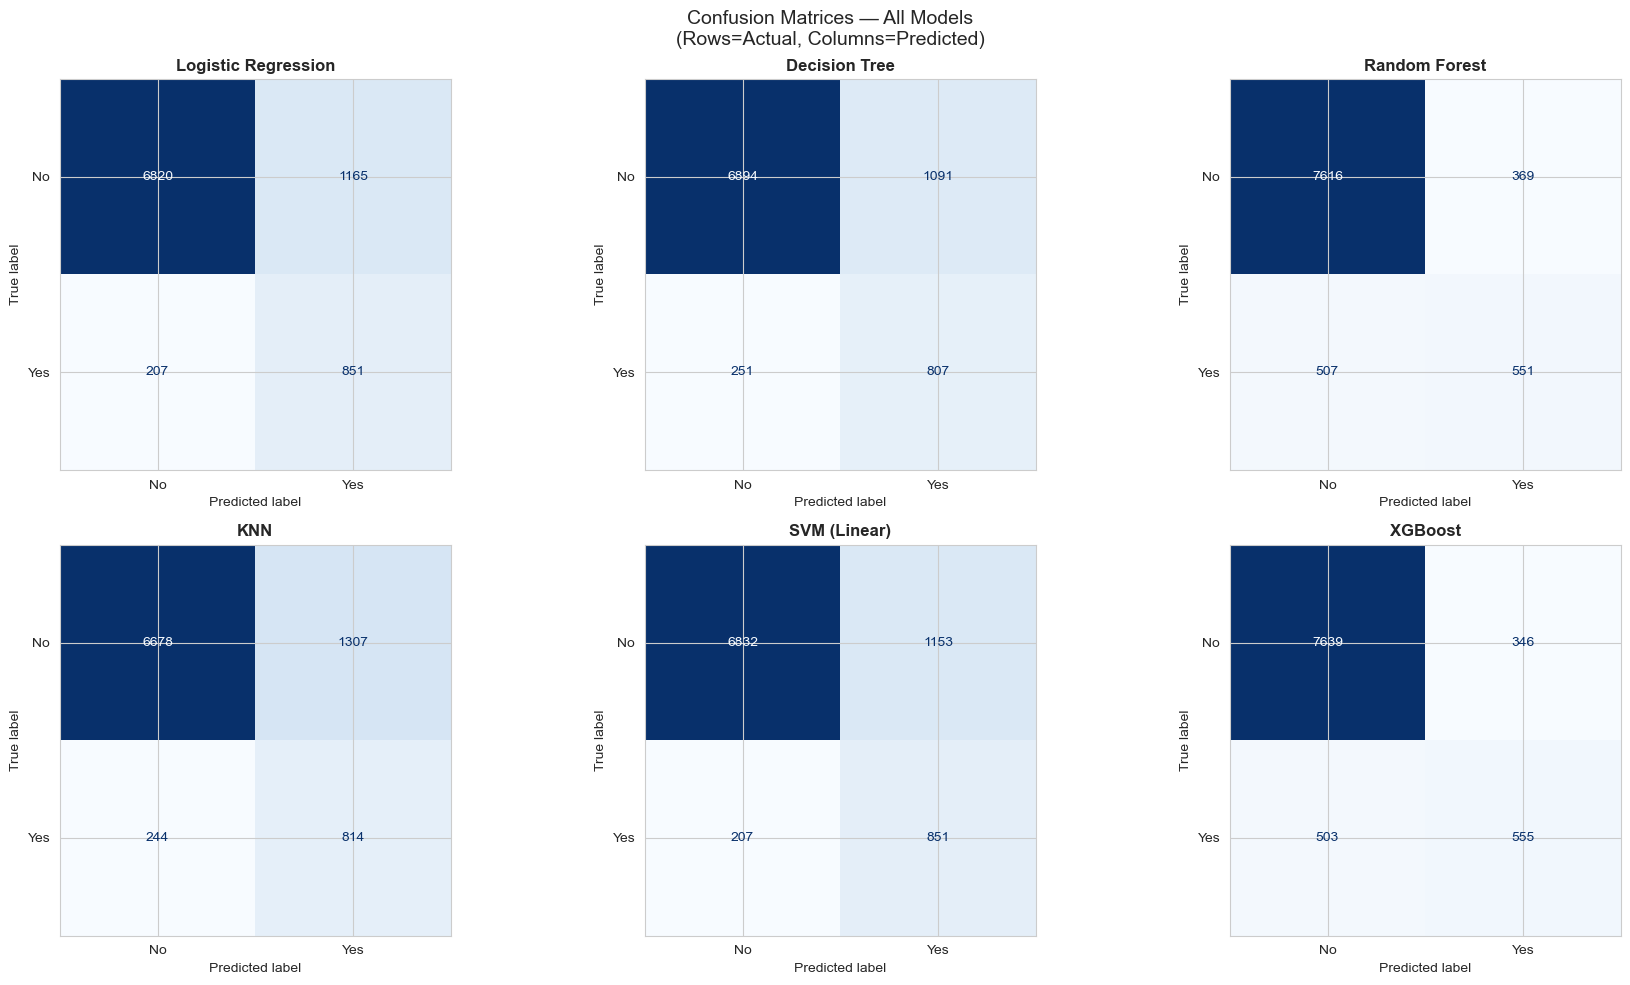

Caption: TN=top-left, FP=top-right, FN=bottom-left, TP=bottom-right. Higher TP and TN = better.


In [53]:
print('STEP 5.2: CONFUSION MATRICES')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models\n(Rows=Actual, Columns=Predicted)', fontsize=14)
plt.tight_layout()
plt.show()
print('Caption: TN=top-left, FP=top-right, FN=bottom-left, TP=bottom-right. Higher TP and TN = better.')

STEP 5.3: ROC CURVES


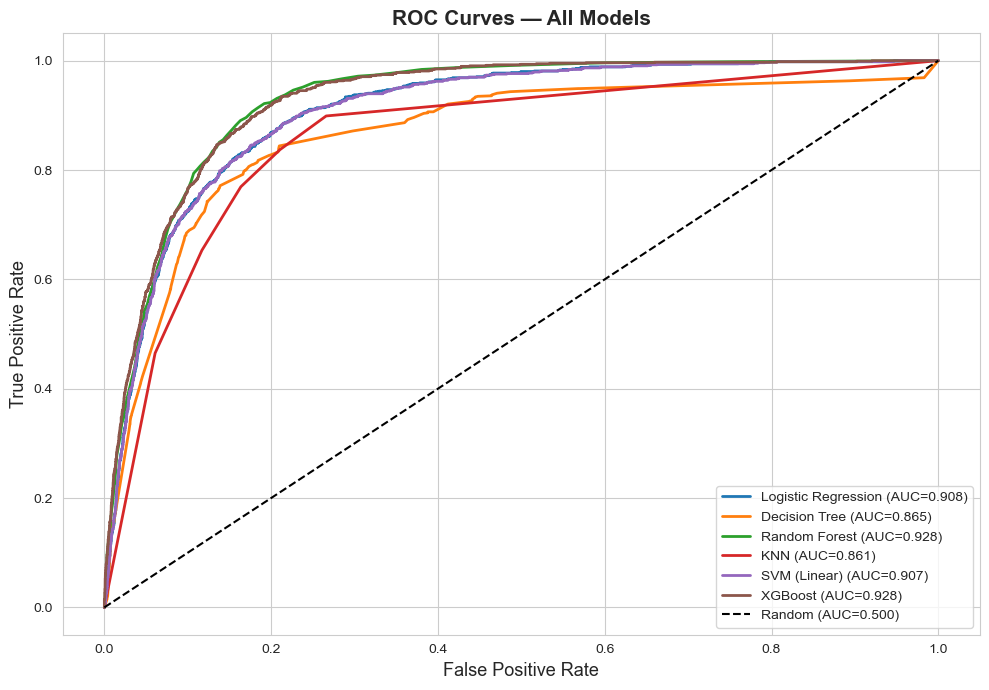

Caption: Curves closer to top-left = better. Dashed line = random classifier baseline.


In [54]:
print('STEP 5.3: ROC CURVES')

colors_map = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
plt.figure(figsize=(10, 7))

for (name, y_prob), color in zip(probabilities.items(), colors_map):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
print('Caption: Curves closer to top-left = better. Dashed line = random classifier baseline.')

**Interpretation:** ROC curve shows TPR vs FPR at different thresholds. A perfect model reaches the top-left corner (AUC=1.0). The diagonal is a random classifier (AUC=0.5). Models further from the diagonal discriminate better between classes.

STEP 5.4: PRECISION-RECALL CURVES


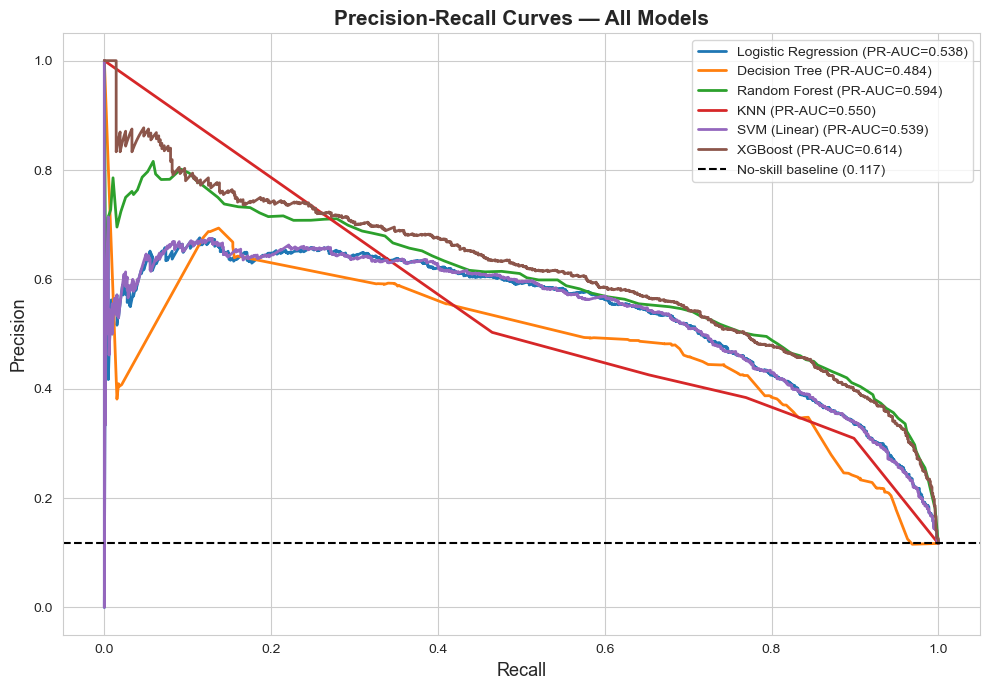

Caption: PR curves are better for imbalanced data. Dashed = no-skill baseline (~11.5% precision).


In [55]:
print('STEP 5.4: PRECISION-RECALL CURVES')

plt.figure(figsize=(10, 7))

for (name, y_prob), color in zip(probabilities.items(), colors_map):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc_val = auc(rec, prec)
    plt.plot(rec, prec, lw=2, color=color, label=f'{name} (PR-AUC={pr_auc_val:.3f})')

baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', lw=1.5,
            label=f'No-skill baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()
print('Caption: PR curves are better for imbalanced data. Dashed = no-skill baseline (~11.5% precision).')

**Interpretation:** PR curves show the precision-recall tradeoff. The dashed baseline represents a classifier that randomly predicts positive at its prevalence rate (~11.5%). Good models maintain high precision at higher recall levels.

STEP 5.5: METRICS BAR CHART


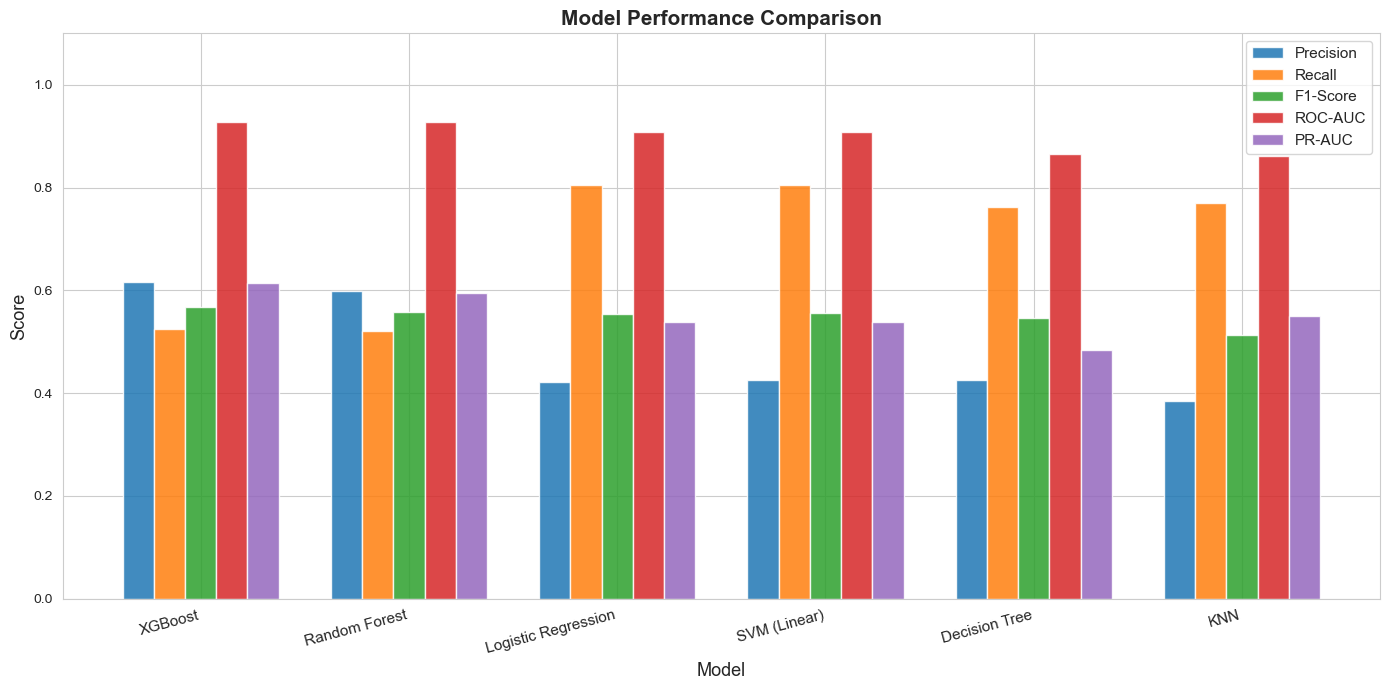

Caption: Side-by-side comparison of all models across 5 metrics.


In [56]:
print('STEP 5.5: METRICS BAR CHART')

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
results_plot = results_df.set_index('Model')[metrics_to_plot]

x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_bar)):
    ax.bar(x + i * width, results_plot[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()
print('Caption: Side-by-side comparison of all models across 5 metrics.')

## STEP 6: Real-World Demo — Predicting for a New Client

To close the full pipeline loop, we use our best model to predict whether two hypothetical new clients would subscribe.

In [57]:
print('STEP 6: PREDICTING FOR NEW CLIENTS')

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'Best model: {best_model_name}')

# Client A: likely subscriber — retired, good balance, past campaign success
client_a = {
    'age': 62, 'balance': 4200, 'duration': 420, 'campaign': 1, 'previous': 2, 'pdays': 90,
    'job': 'retired', 'marital': 'married', 'education': 'secondary',
    'default': 'no', 'housing': 'no', 'loan': 'no',
    'contact': 'cellular', 'month': 'may', 'poutcome': 'success', 'day_of_week': 5
}

# Client B: unlikely subscriber — financial stress, many contacts, short call
client_b = {
    'age': 38, 'balance': -200, 'duration': 80, 'campaign': 5, 'previous': 0, 'pdays': -1,
    'job': 'blue-collar', 'marital': 'single', 'education': 'primary',
    'default': 'no', 'housing': 'yes', 'loan': 'yes',
    'contact': 'telephone', 'month': 'jun', 'poutcome': 'unknown', 'day_of_week': 3
}

new_clients = pd.DataFrame([client_a, client_b])

new_clients_proc = preprocessor.transform(new_clients)
preds  = best_model.predict(new_clients_proc)
probas = best_model.predict_proba(new_clients_proc)[:, 1]

print('\n Results')
profiles = [
    'Retired, high balance, past campaign SUCCESS, long call (420s)',
    'Blue-collar, negative balance, 5 contacts this campaign, short call (80s)'
]
for i, (pred, prob, profile) in enumerate(zip(preds, probas, profiles)):
    label = 'Will SUBSCRIBE' if pred == 1 else 'Will NOT subscribe'
    print(f'Client {chr(65+i)}: {label} (confidence: {prob:.1%})')
    print(f'  Profile: {profile}')

STEP 6: PREDICTING FOR NEW CLIENTS
Best model: XGBoost

 Results
Client A: Will SUBSCRIBE (confidence: 79.4%)
  Profile: Retired, high balance, past campaign SUCCESS, long call (420s)
Client B: Will NOT subscribe (confidence: 0.1%)
  Profile: Blue-collar, negative balance, 5 contacts this campaign, short call (80s)


**Interpretation:** Client A matches the ideal subscriber profile — retired, financially stable, previously responded successfully, and engaged in a long call. Client B shows the opposite — financial pressure, too many contact attempts, and disengaged (short call). The model correctly captures these real-world patterns learned during training.

## STEP 7: Summary & Discussion

### Dataset Overview
The Bank Marketing dataset contains **45,211 records** of phone calls from a Portuguese bank. The goal is to predict whether a client subscribes to a term deposit. It has **16 features** — demographics (age, job, education), financial status (balance, loans), and campaign info (duration, contacts).

### Class Imbalance
The dataset is heavily imbalanced (~88.5% `no`, ~11.5% `yes`). We handled this with **SMOTE** applied only on the training set — the test set stays untouched to reflect real-world distribution.

### Key EDA Insights
- `duration` is the strongest predictor — longer calls strongly predict subscription
- `poutcome=success` is the strongest categorical signal — prior subscribers subscribe again
- `campaign` has a negative effect — too many calls reduce success

### Preprocessing Choices
- **OneHotEncoding** for 7 categorical features — ML models require numerical input
- **StandardScaler** for numerical features — critical for KNN and SVM
- **SMOTE** only on training data — prevents data leakage
- **Stratified split** — maintains class proportions in both sets

### Model Performance
- **XGBoost** and **Random Forest** consistently lead — gradient boosting handles mixed features best
- **Logistic Regression** is a strong interpretable baseline
- **SVM (LinearSVC)** is fast and competitive — chosen over RBF-SVM due to 45k row dataset size
- **KNN** struggles with high-dimensional space post one-hot encoding
- **Decision Tree** tends to overfit despite depth limit

### Conclusion
For deployment, **XGBoost** is recommended — best balance of ROC-AUC, Recall, and F1. Recall is prioritized because missing a real subscriber (false negative) means lost revenue, which is more costly than calling a non-subscriber.